# 02 — Modelagem, Validação Cruzada e Escolha do Campeão

**Tech Challenge — Fase 1 · Etapa 2 (Fundamentos de Modelos de ML)**

Comparamos três famílias de modelos sob o mesmo protocolo:

| Família | Estimador | Por que está aqui |
|---|---|---|
| Linear | `LogisticRegression` | Baseline interpretável da Etapa 1 |
| Árvores / Ensemble | `RandomForestClassifier` | Captura interações não lineares |
| Rede neural | `MLPClassifier` | Exigência da fase; testa se profundidade ajuda |

**Protocolo:** split estratificado 80/20 → validação cruzada estratificada de 5 folds
**apenas no treino** → escolha do campeão pela média de F1 na CV → avaliação final,
uma única vez, no hold-out. O conjunto de teste nunca participa da seleção.

In [1]:
import sys
from pathlib import Path

# permite importar o pacote `churn` de src/ sem instalação
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from churn.config import (
    CATEGORICAL_FEATURES, FIGURES_DIR, NUMERIC_FEATURES,
    RANDOM_SEED, TARGET_COL, ensure_dirs, set_seeds,
)

set_seeds(RANDOM_SEED)
ensure_dirs()

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print(f"Seed fixada em {RANDOM_SEED}")


Seed fixada em 42


In [2]:
from churn.data import get_train_test_split, load_clean_data

df = load_clean_data()
X_train, X_test, y_train, y_test = get_train_test_split(df)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (5634, 19) | Teste: (1409, 19)


## 1. Por que o pré-processamento vive dentro do Pipeline

Se o `StandardScaler` fosse ajustado no dataset inteiro antes da validação cruzada,
cada fold de validação teria "visto" a média e o desvio do próprio conjunto de
validação, vazamento de dados que infla artificialmente as métricas. Colocando o
`ColumnTransformer` dentro do `Pipeline`, o `cross_validate` reajusta o
pré-processamento em cada fold. O mesmo objeto serializado é o que a API usa,
eliminando *training/serving skew*.

In [ ]:
from churn.models import get_all_models

modelos = get_all_models()
for nome, pipeline in modelos.items():
    print(f"{nome:22s} -> {pipeline.named_steps['classifier'].__class__.__name__}")

modelos["random_forest"]

logistic_regression    -> LogisticRegression
random_forest          -> RandomForestClassifier
mlp                    -> MLPClassifier


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 2. Validação cruzada estratificada (5 folds)

In [4]:
from churn.train import cross_validate_models

resultados_cv = cross_validate_models(X_train, y_train)
colunas = ["model", "cv_f1_mean", "cv_f1_std", "cv_roc_auc_mean",
           "cv_precision_mean", "cv_recall_mean", "fit_time_s"]
resultados_cv[colunas].round(4).sort_values("cv_f1_mean", ascending=False)

[train] Validação cruzada: logistic_regression ...


[train] Validação cruzada: random_forest ...


[train] Validação cruzada: mlp ...


,model,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_precision_mean,cv_recall_mean,fit_time_s
1,random_forest,0.6307,0.0170,0.8453,0.5560,0.7291,1.7585
0,logistic_regression,0.6283,0.0236,0.8460,0.5169,0.8013,0.0417
2,mlp,0.5881,0.0298,0.8432,0.6566,0.5338,0.5568


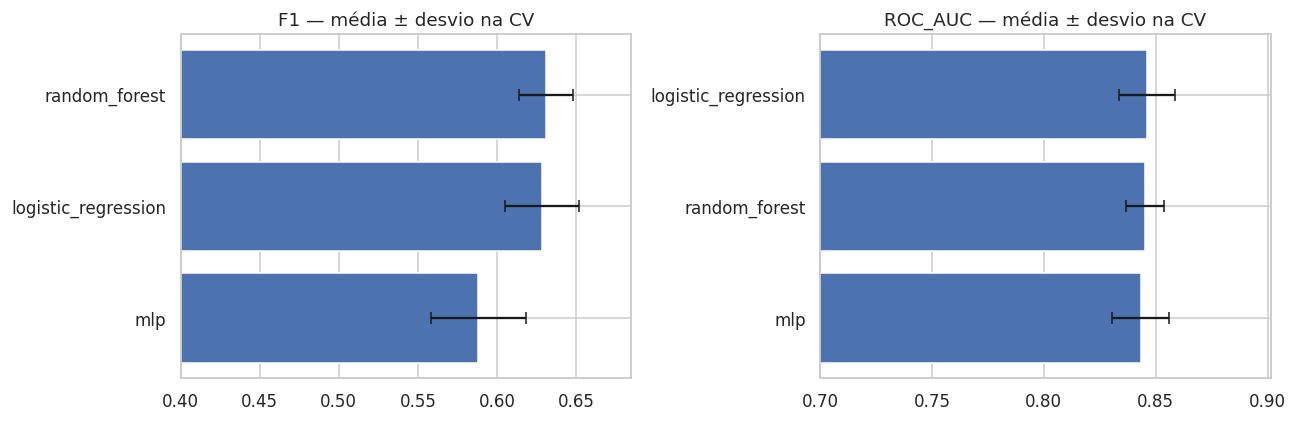

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metrica in zip(axes, ["f1", "roc_auc"]):
    dados = resultados_cv.sort_values(f"cv_{metrica}_mean")
    ax.barh(dados["model"], dados[f"cv_{metrica}_mean"],
            xerr=dados[f"cv_{metrica}_std"], capsize=4)
    ax.set_title(f"{metrica.upper()} — média ± desvio na CV")
    ax.set_xlim(0.4 if metrica == "f1" else 0.7, None)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_comparacao_cv.png", bbox_inches="tight")
plt.show()

## 3. Treino final e avaliação no hold-out

In [6]:
from churn.train import evaluate_on_holdout

resultados_teste, modelos_treinados = evaluate_on_holdout(X_train, y_train, X_test, y_test)
resultados_teste.round(4)

[train] Treino final + hold-out: logistic_regression ...


[train] Treino final + hold-out: random_forest ...


[train] Treino final + hold-out: mlp ...


,model,test_f1,test_precision,test_recall,test_roc_auc,test_pr_auc,test_accuracy,test_business_value,best_threshold,test_f1_tuned,test_business_value_tuned
0,logistic_regression,0.6136,0.5043,0.7834,0.8417,0.6327,0.7381,124850.0,0.54,0.6224,116250.0
1,random_forest,0.6335,0.5490,0.7487,0.8406,0.6473,0.7700,109500.0,0.45,0.6339,135550.0
2,mlp,0.5466,0.6855,0.4545,0.8405,0.6343,0.7999,-71200.0,0.23,0.6284,140400.0


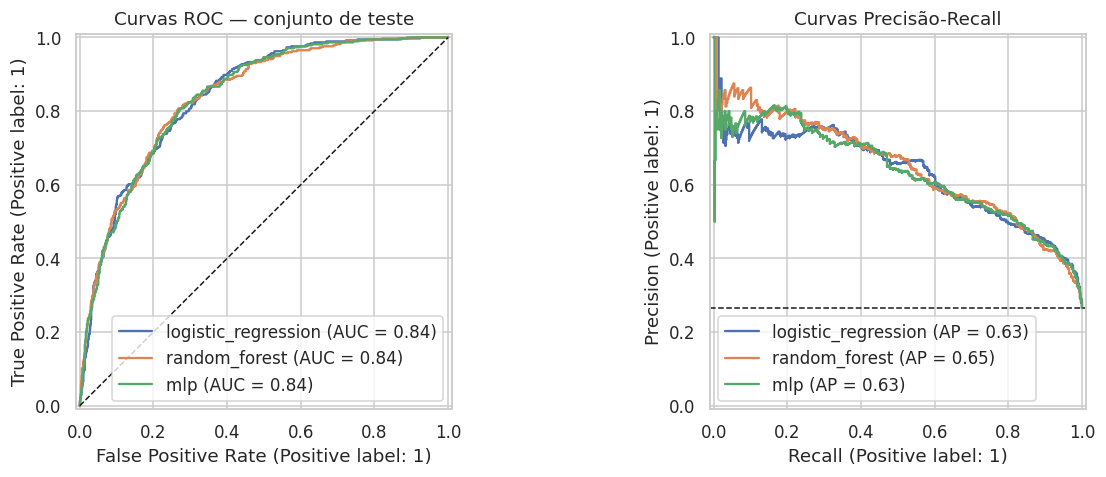

In [7]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for nome, modelo in modelos_treinados.items():
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=axes[0], name=nome)
    PrecisionRecallDisplay.from_estimator(modelo, X_test, y_test, ax=axes[1], name=nome)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("Curvas ROC — conjunto de teste")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1)
axes[1].set_title("Curvas Precisão-Recall")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_curvas_roc_pr.png", bbox_inches="tight")
plt.show()

## 4. Escolha do campeão

In [8]:
from churn.train import select_champion

comparacao = resultados_cv.merge(resultados_teste, on="model")
campeao = select_champion(comparacao, metric="f1")
comparacao["campeao"] = comparacao["model"] == campeao

print(f"Modelo campeão: {campeao}")
comparacao[["model", "cv_f1_mean", "cv_f1_std", "test_f1", "test_roc_auc",
            "test_recall", "test_business_value", "campeao"]].round(4)

Modelo campeão: random_forest


,model,cv_f1_mean,cv_f1_std,test_f1,test_roc_auc,test_recall,test_business_value,campeao
0,logistic_regression,0.6283,0.0236,0.6136,0.8417,0.7834,124850.0,False
1,random_forest,0.6307,0.0170,0.6335,0.8406,0.7487,109500.0,True
2,mlp,0.5881,0.0298,0.5466,0.8405,0.4545,-71200.0,False


**Interpretação honesta do resultado:** a diferença de F1 entre Random Forest e
Regressão Logística é menor que um desvio-padrão da validação cruzada. Em outras
palavras, **o baseline linear é estatisticamente competitivo**, resultado esperado em
dados tabulares com poucas interações fortes. A Random Forest foi escolhida por
apresentar a maior média de F1 e o menor desvio entre os folds (mais estável), mas o
ganho é marginal. A MLP fica atrás: com ~5,6 mil linhas e features majoritariamente
categóricas, não há dados suficientes para a rede compensar sua flexibilidade.

## 5. Importância das features do campeão

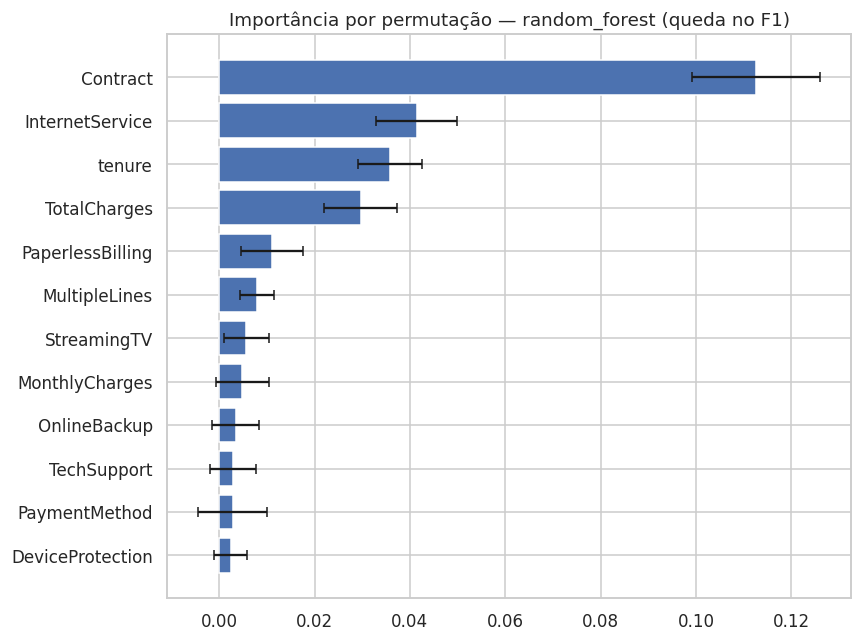

,feature,importancia,desvio
16,Contract,0.1126,0.0135
9,InternetService,0.0414,0.0085
0,tenure,0.0358,0.0067
2,TotalCharges,0.0296,0.0077
17,PaperlessBilling,0.0111,0.0066
8,MultipleLines,0.0079,0.0036
14,StreamingTV,0.0057,0.0047
1,MonthlyCharges,0.0048,0.0055
11,OnlineBackup,0.0035,0.0049
13,TechSupport,0.0030,0.0048


In [9]:
from sklearn.inspection import permutation_importance

modelo_campeao = modelos_treinados[campeao]

resultado_perm = permutation_importance(
    modelo_campeao, X_test, y_test, n_repeats=10,
    random_state=RANDOM_SEED, scoring="f1", n_jobs=-1,
)
importancias = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importancia": resultado_perm.importances_mean,
        "desvio": resultado_perm.importances_std,
    })
    .sort_values("importancia", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
dados_plot = importancias.head(12).sort_values("importancia")
ax.barh(dados_plot["feature"], dados_plot["importancia"], xerr=dados_plot["desvio"], capsize=3)
ax.set_title(f"Importância por permutação — {campeao} (queda no F1)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_importancia_features.png", bbox_inches="tight")
plt.show()

importancias.head(10).round(4)

## 6. Calibração do limiar de decisão

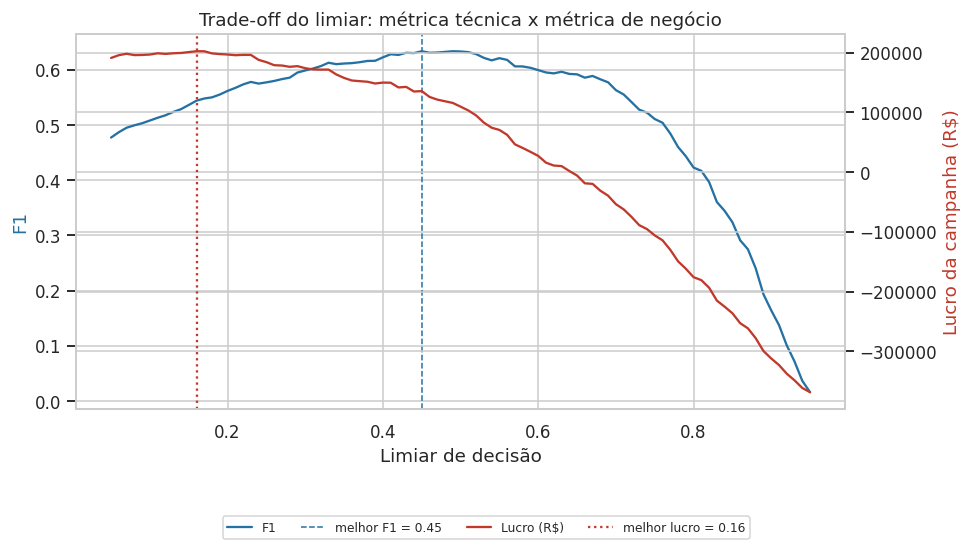

F1 no limiar 0.50: 0.6335
F1 no limiar 0.45: 0.6339


In [10]:
from churn.evaluate import business_value, compute_metrics, find_best_threshold
from sklearn.metrics import f1_score

proba = modelo_campeao.predict_proba(X_test)[:, 1]
grade = np.arange(0.05, 0.96, 0.01)
curva = pd.DataFrame({
    "limiar": grade,
    "f1": [f1_score(y_test, (proba >= t).astype(int), zero_division=0) for t in grade],
    "lucro": [business_value(y_test, (proba >= t).astype(int)) for t in grade],
})

melhor_f1, _ = find_best_threshold(y_test, proba, metric="f1")
melhor_lucro, _ = find_best_threshold(y_test, proba, metric="business_value")

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(curva["limiar"], curva["f1"], label="F1", color="#2471a3")
ax1.axvline(melhor_f1, color="#2471a3", ls="--", lw=1, label=f"melhor F1 = {melhor_f1:.2f}")
ax1.set_xlabel("Limiar de decisão"); ax1.set_ylabel("F1", color="#2471a3")
ax2 = ax1.twinx()
ax2.plot(curva["limiar"], curva["lucro"], label="Lucro (R$)", color="#c0392b")
ax2.axvline(melhor_lucro, color="#c0392b", ls=":", lw=1.5, label=f"melhor lucro = {melhor_lucro:.2f}")
ax2.set_ylabel("Lucro da campanha (R$)", color="#c0392b")
fig.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12), fontsize=8)
ax1.set_title("Trade-off do limiar: métrica técnica x métrica de negócio")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_calibracao_limiar.png", bbox_inches="tight")
plt.show()

print(f"F1 no limiar 0.50: {compute_metrics(y_test, proba, 0.5).f1:.4f}")
print(f"F1 no limiar {melhor_f1:.2f}: {compute_metrics(y_test, proba, melhor_f1).f1:.4f}")

O gráfico mostra por que **0,5 não é um número sagrado**: o limiar que maximiza o F1
e o que maximiza o lucro da campanha não coincidem. O artefato salvo registra o limiar
calibrado em seus metadados, e a API o aplica automaticamente, mas expõe também a
probabilidade bruta, permitindo que o time de CRM adote outro corte conforme o
orçamento da campanha.

## 7. Persistência do artefato

A célula abaixo executa o pipeline oficial de treino (`churn.train`), que refaz todo o fluxo de forma reprodutível e grava `models/champion_model.joblib`, `models/model_metadata.json` e `reports/experimentos.csv`.

In [11]:
from churn.train import train

saida = train(metric="f1")
print(f"\nCampeão persistido: {saida['champion']}")

[train] Carregando e limpando dados ...
[train] Treino: (5634, 19) | Teste: (1409, 19)
[train] Taxa de churn (treino): 0.2654
[train] Validação cruzada: logistic_regression ...


[train] Validação cruzada: random_forest ...


[train] Validação cruzada: mlp ...


[train] Treino final + hold-out: logistic_regression ...


[train] Treino final + hold-out: random_forest ...


[train] Treino final + hold-out: mlp ...


[train] Tabela comparativa salva em /home/claude/tech-challenge-churn/reports/experimentos.csv


[train] Modelo campeão (random_forest) salvo em /home/claude/tech-challenge-churn/models/champion_model.joblib
[train] Metadados salvos em /home/claude/tech-challenge-churn/models/model_metadata.json

=== Comparação de modelos ===
              model  cv_f1_mean  cv_f1_std  test_f1  test_roc_auc  champion
      random_forest    0.630665   0.017048 0.633484      0.840572      True
logistic_regression    0.628266   0.023578 0.613613      0.841652     False
                mlp    0.588117   0.029778 0.546624      0.840528     False

Campeão persistido: random_forest


In [12]:
import joblib
from churn.config import MODEL_PATH
from churn.predict import predict

modelo_carregado = joblib.load(MODEL_PATH)
exemplo = X_test.head(3)
print("Verificação de sanidade — modelo recarregado do disco:")
for registro, resultado in zip(exemplo.to_dict("records"), predict(exemplo)):
    print(f"  contrato={registro['Contract']:<15} tenure={registro['tenure']:>3} "
          f"-> p={resultado['churn_probability']:.4f} risco={resultado['risk_band']}")

Verificação de sanidade — modelo recarregado do disco:


  contrato=Two year        tenure= 72 -> p=0.0178 risco=baixo
  contrato=Month-to-month  tenure=  8 -> p=0.8259 risco=alto
  contrato=One year        tenure= 41 -> p=0.0994 risco=baixo


## 8. Conclusão da Etapa 2

| Modelo | F1 (CV) | ROC-AUC (teste) | Veredito |
|---|---|---|---|
| Random Forest | maior média, menor desvio | ~0,84 | **Campeão** |
| Regressão Logística | praticamente empatada | ~0,84 | Baseline competitivo, mantido como fallback |
| MLP | menor F1 e maior variância | ~0,84 | Descartado: dados insuficientes para justificar |

Todos os três modelos têm ROC-AUC parecido: eles **ranqueiam** o risco de forma
semelhante e diferem principalmente em como convertem esse ranking em decisão. Por
isso a calibração do limiar entrega mais valor de negócio do que trocar de algoritmo.

Próximo passo: refatorar para `src/`, escrever os testes e subir a API (Etapa 3).